In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, GATv2Conv
import pandas as pd
import numpy as np
import networkx as nx
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

# Load and preprocess data
df = pd.read_csv("Merged_Data(Spatio-temporal).csv")
df = df[['Station_ID', 'Ozone', 'NO2', 'PM2.5', 'Lat', 'Lon',
         'NO2_prev_day', 'PM2.5_prev_day', 'Ozone_prev_day', 'NO2_prev_week',
         'PM2.5_prev_week', 'Ozone_prev_week', 'Spatial_Avg_PM2.5',
         'Spatial_Avg_Ozone', 'Spatial_Avg_NO2']]
df.dropna(inplace=True)
df = df.head(10)
df.reset_index(drop=True, inplace=True)  # <-- Important fix

# Normalize features (excluding Station_ID and spatial columns)
features = df.columns.difference(['Station_ID', 'Lat', 'Lon'])
scaler = StandardScaler()
df[features] = scaler.fit_transform(df[features])

In [2]:
# Graph construction based on feature distances only
def construct_graph_dynamic(df, k=5):
    G = nx.Graph()

    feature_cols = ['NO2_prev_day', 'PM2.5_prev_day', 'Ozone_prev_day',
                    'NO2_prev_week', 'PM2.5_prev_week', 'Ozone_prev_week',
                    'Spatial_Avg_PM2.5', 'Spatial_Avg_Ozone', 'Spatial_Avg_NO2']

    feature_nbrs = NearestNeighbors(n_neighbors=k).fit(df[feature_cols])
    feature_distances, feature_indices = feature_nbrs.kneighbors(df[feature_cols])

    for i, row in df.iterrows():
        G.add_node(row['Station_ID'])

        for j, feature_dist in zip(feature_indices[i], feature_distances[i]):
            if row['Station_ID'] != df.loc[j, 'Station_ID']:
                G.add_edge(row['Station_ID'], df.loc[j, 'Station_ID'], weight=np.exp(-feature_dist))
    return G
G = construct_graph_dynamic(df, k=5)

In [10]:
def graph_to_pyg(G, df_subset):
    # Keep only nodes existing in both G and df
    stations = df_subset['Station_ID'].unique()
    valid_nodes = [n for n in G.nodes if n in stations]

    # Map StationID ➝ index (0...N)
    node_map = {station: i for i, station in enumerate(valid_nodes)}

    # Create valid edge list
    edges = []
    for u, v in G.edges():
        if u in node_map and v in node_map:
            edges.append([node_map[u], node_map[v]])

    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

    # Make graph undirected
    edge_index = torch.cat([edge_index, edge_index.flip(0)], dim=1)

    # Feature matrix (Station_ID REMOVED)
    x = torch.tensor(
        df_subset[df_subset['Station_ID'].isin(valid_nodes)][[
            'Ozone','NO2_prev_day','PM2.5_prev_day','Ozone_prev_day',
            'NO2_prev_week','PM2.5_prev_week','Ozone_prev_week',
            'Spatial_Avg_PM2.5','Spatial_Avg_Ozone','Spatial_Avg_NO2'
        ]].values,
        dtype=torch.float32
    )

    # Target
    y = torch.tensor(
        df_subset[df_subset['Station_ID'].isin(valid_nodes)][
            ['NO2', 'PM2.5']
        ].values,
        dtype=torch.float32
    )

    return Data(x=x, edge_index=edge_index, y=y)


In [11]:
# Hybrid GCN + Multi-GATv2 Model with BatchNorm and Dropout
class StackedGNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, heads=2, dropout=0.3):
        super(StackedGNN, self).__init__()
        self.gcn = GCNConv(input_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.gat1 = GATv2Conv(hidden_dim, hidden_dim, heads=heads, concat=True)
        self.bn2 = nn.BatchNorm1d(hidden_dim * heads)
        self.gat2 = GATv2Conv(hidden_dim * heads, hidden_dim, heads=heads, concat=True)
        self.bn3 = nn.BatchNorm1d(hidden_dim * heads)
        self.gat3 = GATv2Conv(hidden_dim * heads, hidden_dim, heads=heads, concat=True)
        self.bn4 = nn.BatchNorm1d(hidden_dim * heads)
        self.fc = nn.Linear(hidden_dim * heads, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, edge_index):
        x = torch.relu(self.bn1(self.gcn(x, edge_index)))
        x = self.dropout(x)
        x = torch.relu(self.bn2(self.gat1(x, edge_index)))
        x = self.dropout(x)
        x = torch.relu(self.bn3(self.gat2(x, edge_index)))
        x = self.dropout(x)
        x = torch.relu(self.bn4(self.gat3(x, edge_index)))
        x = self.dropout(x)
        return self.fc(x)

In [15]:
import torch
import torch.nn as nn
from torch_geometric.nn import GCNConv, GATv2Conv
from torchviz import make_dot

# ===============================
# 1. MODEL DEFINITION (YOUR ARCHITECTURE)
# ===============================
class StackedGNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, heads=2, dropout=0.3):
        super(StackedGNN, self).__init__()

        self.gcn = GCNConv(input_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)

        self.gat1 = GATv2Conv(hidden_dim, hidden_dim, heads=heads, concat=True)
        self.bn2 = nn.BatchNorm1d(hidden_dim * heads)

        self.gat2 = GATv2Conv(hidden_dim * heads, hidden_dim, heads=heads, concat=True)
        self.bn3 = nn.BatchNorm1d(hidden_dim * heads)

        self.gat3 = GATv2Conv(hidden_dim * heads, hidden_dim, heads=heads, concat=True)
        self.bn4 = nn.BatchNorm1d(hidden_dim * heads)

        self.fc = nn.Linear(hidden_dim * heads, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, edge_index):

        x = torch.relu(self.bn1(self.gcn(x, edge_index)))
        x = self.dropout(x)

        x = torch.relu(self.bn2(self.gat1(x, edge_index)))
        x = self.dropout(x)

        x = torch.relu(self.bn3(self.gat2(x, edge_index)))
        x = self.dropout(x)

        x = torch.relu(self.bn4(self.gat3(x, edge_index)))
        x = self.dropout(x)

        return self.fc(x)


# ===============================
# 2. DUMMY DATA (FIXED)
# ===============================
num_nodes  = 8
input_dim  = 10
hidden_dim = 32
output_dim = 1
heads      = 2

# Node features: (nodes, input_features)
dummy_x = torch.randn((num_nodes, input_dim))

# Edge connections
dummy_edge = torch.tensor([
    [0,1,2,3,4,5,6,7,1,2,3],
    [1,2,3,4,5,6,7,0,5,6,4]
], dtype=torch.long)

# ===============================
# 3. CREATE MODEL
# ===============================
model = StackedGNN(
    input_dim=input_dim,
    hidden_dim=hidden_dim,
    output_dim=output_dim,
    heads=heads,
    dropout=0.3
)

print(model)

# ===============================
# 4. GENERATE ARCHITECTURE DIAGRAM
# ===============================
with torch.no_grad():
    output = model(dummy_x, dummy_edge)

dot = make_dot(output, params=dict(model.named_parameters()))

# Clean paper style
dot.graph_attr.update(bgcolor='white', rankdir='TB')
dot.node_attr.update(color='black', fontname='Times-Roman', shape='box')
dot.edge_attr.update(color='black')

dot.format = 'png'
dot.render('StackedGNN_Architecture', cleanup=True)

print("\n✅ Architecture diagram saved as: StackedGNN_Architecture.png")


StackedGNN(
  (gcn): GCNConv(10, 32)
  (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (gat1): GATv2Conv(32, 32, heads=2)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (gat2): GATv2Conv(64, 32, heads=2)
  (bn3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (gat3): GATv2Conv(64, 32, heads=2)
  (bn4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH

In [12]:
# Prepare data
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
train_data = graph_to_pyg(G, train_df)
test_data = graph_to_pyg(G, test_df)

In [6]:
# Evaluation
def evaluate_model(model, data, target_names):
    model.eval()
    with torch.no_grad():
        predictions = model(data.x, data.edge_index).cpu().numpy()
        actual = data.y.cpu().numpy()

    for i, name in enumerate(target_names):
        y_true = actual[:, i]
        y_pred = predictions[:, i]
        print(f"\n{name} Performance:")
        print(f"  MSE   : {mean_squared_error(y_true, y_pred):.4f}")
        print(f"  MAE   : {mean_absolute_error(y_true, y_pred):.4f}")
        print(f"  R2    : {r2_score(y_true, y_pred):.4f}")
        print(f"  MAPE  : {mean_absolute_percentage_error(y_true, y_pred):.4f}")
        print(f"  NRMSE : {np.sqrt(mean_squared_error(y_true, y_pred)) / (y_true.max() - y_true.min()):.4f}")

In [7]:
# Prepare data
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
train_data = graph_to_pyg(G, train_df)
test_data = graph_to_pyg(G, test_df)

# Move to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_data = train_data.to(device)
test_data = test_data.to(device)

# Model setup
input_dim = train_data.x.shape[1]
model = StackedGNN(input_dim=input_dim, hidden_dim=64, output_dim=2, heads=2, dropout=0.3).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=200, gamma=0.7)

# Loss
def combined_loss(output, target):
    return nn.MSELoss()(output, target) + 0.3 * nn.L1Loss()(output, target)

# Training
best_loss = float('inf')
patience = 100
counter = 0
epochs = 1

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    output = model(train_data.x, train_data.edge_index)
    loss = combined_loss(output, train_data.y)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    scheduler.step()

    if loss.item() < best_loss:
        best_loss = loss.item()
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    if epoch % 50 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.4f}")

# Final Evaluation
evaluate_model(model, test_data, target_names=["NO2", "PM2.5"])


RuntimeError: index 13 is out of bounds for dimension 0 with size 8

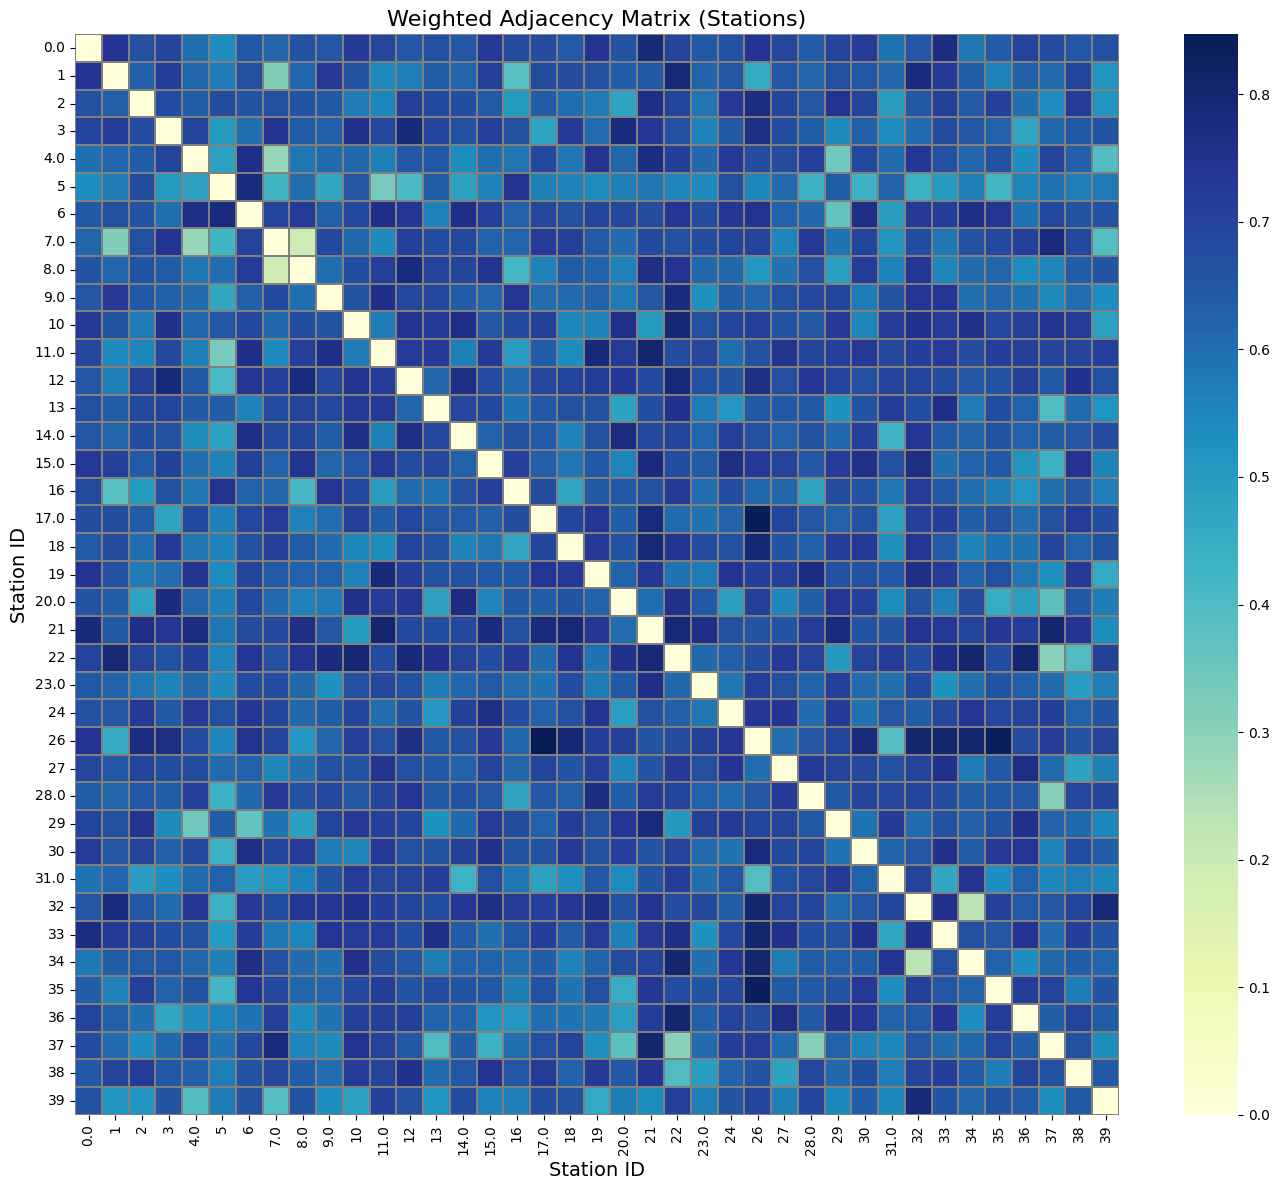

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_weighted_adjacency_matrix_with_labels(G):
    # Get sorted list of nodes
    nodes = sorted(G.nodes())
    node_to_idx = {node: i for i, node in enumerate(nodes)}

    # Initialize adjacency matrix
    adj_matrix = np.zeros((len(nodes), len(nodes)))

    for u, v, data in G.edges(data=True):
        i, j = node_to_idx[u], node_to_idx[v]
        weight = data['weight']
        adj_matrix[i, j] = weight
        adj_matrix[j, i] = weight  # Since undirected

    # Plot heatmap
    plt.figure(figsize=(14, 12))
    sns.heatmap(adj_matrix, 
                xticklabels=nodes, 
                yticklabels=nodes, 
                cmap='YlGnBu', 
                linewidths=0.3,
                linecolor='gray')
    plt.title("Weighted Adjacency Matrix (Stations)", fontsize=16)
    plt.xlabel("Station ID", fontsize=14)
    plt.ylabel("Station ID", fontsize=14)
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Usage
plot_weighted_adjacency_matrix_with_labels(G)
